In [ ]:
"""
 NOTEBOOK 1: ML MODEL TRAINING FOR PHISHING DETECTION
 DATASET: https://www.kaggle.com/datasets/shashwatwork/web-page-phishing-detection-dataset
"""

'\n=============================================================================\n NOTEBOOK 1: ML MODEL TRAINING FOR PHISHING DETECTION\n=============================================================================\n Platform: Google Colab or Kaggle\n\n HOW TO USE:\n   1. Open Google Colab (colab.research.google.com)\n   2. Create a new notebook\n   3. Copy each section (separated by "# %%") into a separate cell\n   4. Run cells in order from top to bottom\n   5. Download the exported model files at the end\n\n DATASET: https://www.kaggle.com/datasets/shashwatwork/web-page-phishing-detection-dataset\n=============================================================================\n'

In [ ]:
# [1] INSTALL DEPENDENCIES

!pip install pandas numpy scikit-learn xgboost matplotlib seaborn joblib kagglehub

In [ ]:
# [2] IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)
from sklearn.preprocessing import StandardScaler, LabelEncoder

try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
    print("XGBoost available")
except ImportError:
    HAS_XGBOOST = False
    print("XGBoost not available, will use GradientBoosting as fallback")
print("All libraries loaded successfully!")

XGBoost available
All libraries loaded successfully!


In [ ]:
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

In [ ]:
# [3] DOWNLOAD & LOAD DATASET FROM KAGGLE
try:
    import kagglehub
    path = kagglehub.dataset_download("shashwatwork/web-page-phishing-detection-dataset")
    print(f"✅ Dataset downloaded to: {path}")

    # Find the CSV file
    for root, dirs, files in os.walk(path):
        for f in files:
            if f.endswith('.csv'):
                csv_path = os.path.join(root, f)
                print(f"📄 Found CSV: {csv_path}")
                break

    df = pd.read_csv(csv_path)
except Exception as e:
    print(f"⚠️ kagglehub failed: {e}")
    print("📁 Trying to load from uploaded file or Kaggle input...")

100%|██████████| 1.01M/1.01M [00:00<00:00, 87.2MB/s]

Extracting files...
✅ Dataset downloaded to: /root/.cache/kagglehub/datasets/shashwatwork/web-page-phishing-detection-dataset/versions/2
📄 Found CSV: /root/.cache/kagglehub/datasets/shashwatwork/web-page-phishing-detection-dataset/versions/2/dataset_phishing.csv


In [ ]:
# %% [4] DATA EXPLORATION

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"\n📊 Total samples: {len(df)}")
print(f"\n📊 Data types:\n{df.dtypes}")
print(f"\n📊 Missing values:\n{df.isnull().sum()}")
print(f"\n📊 Dataset info:")
df.info()

DATASET OVERVIEW

📊 Total samples: 11430

📊 Data types:
url                object
length_url          int64
length_hostname     int64
ip                  int64
nb_dots             int64
                    ...  
web_traffic         int64
dns_record          int64
google_index        int64
page_rank           int64
status             object
Length: 89, dtype: object

📊 Missing values:
url                0
length_url         0
length_hostname    0
ip                 0
nb_dots            0
                  ..
web_traffic        0
dns_record         0
google_index       0
page_rank          0
status             0
Length: 89, dtype: int64

📊 Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11430 entries, 0 to 11429
Data columns (total 89 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   url                         11430 non-null  object 
 1   length_url                  11430 non-null  int64  
 2 

In [ ]:
# Check target column
target_col = None
for col in df.columns:
    if col.lower() in ['status', 'label', 'target', 'phishing', 'class', 'result']:
        target_col = col
        break

if target_col is None:
    # Try the last column
    target_col = df.columns[-1]
    print(f"⚠️ Guessing target column: '{target_col}'")
else:
    print(f"✅ Target column: '{target_col}'")

print(f"\n📊 Target distribution:\n{df[target_col].value_counts()}")
print(f"\n📊 Target distribution (%):\n{df[target_col].value_counts(normalize=True) * 100}")


✅ Target column: 'status'

📊 Target distribution:
status
legitimate    5715
phishing      5715
Name: count, dtype: int64

📊 Target distribution (%):
status
legitimate    50.0
phishing      50.0
Name: proportion, dtype: float64


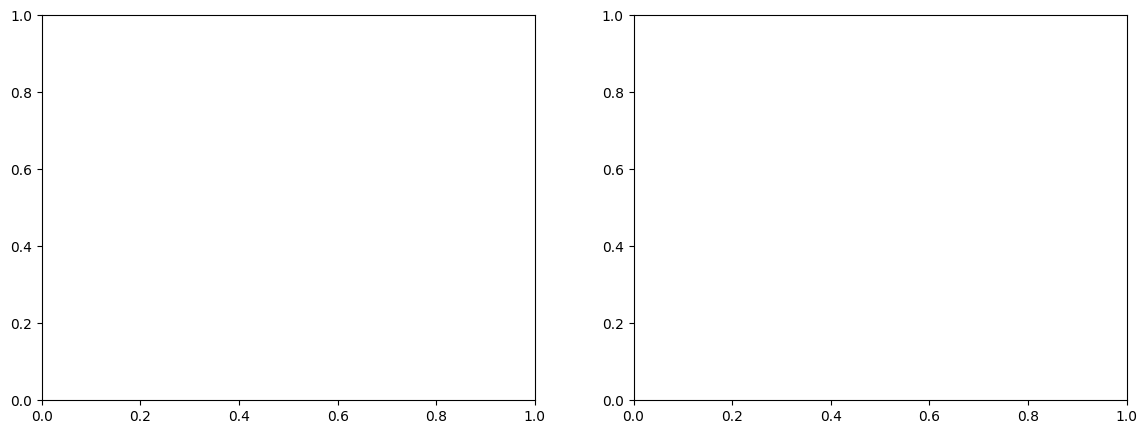

In [ ]:
# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

In [ ]:
# Bar chart
df[target_col].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Target Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')

Text(4.444444444444452, 0.5, 'Count')

In [ ]:
# Pie chart
df[target_col].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                     colors=['#2ecc71', '#e74c3c'],
                                     startangle=90)
axes[1].set_title('Target Distribution (%)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [ ]:
# %% [5] FEATURE ENGINEERING & PREPROCESSING

print("=" * 60)
print("FEATURE ENGINEERING")
print("=" * 60)
# Identify feature columns (everything except target and any URL/index columns)
exclude_cols = [target_col]
url_col = None

for col in df.columns:
    if col.lower() in ['url', 'urls', 'web_url', 'domain']:
        exclude_cols.append(col)
        url_col = col
        print(f"📝 Found URL column: '{col}' (will be excluded from features)")

FEATURE ENGINEERING
📝 Found URL column: 'url' (will be excluded from features)


In [ ]:
# If there's a URL column, extract additional features from it
if url_col and url_col in df.columns:
    print("\n🔧 Extracting additional features from URLs...")

    df['url_length'] = df[url_col].astype(str).apply(len)
    df['url_n_dots'] = df[url_col].astype(str).apply(lambda x: x.count('.'))
    df['url_n_hyphens'] = df[url_col].astype(str).apply(lambda x: x.count('-'))
    df['url_n_slashes'] = df[url_col].astype(str).apply(lambda x: x.count('/'))
    df['url_n_at'] = df[url_col].astype(str).apply(lambda x: x.count('@'))
    df['url_n_qmark'] = df[url_col].astype(str).apply(lambda x: x.count('?'))
    df['url_n_equal'] = df[url_col].astype(str).apply(lambda x: x.count('='))
    df['url_n_ampersand'] = df[url_col].astype(str).apply(lambda x: x.count('&'))
    df['url_has_ip'] = df[url_col].astype(str).apply(
        lambda x: 1 if any(c.isdigit() for c in x.split('/')[2] if '/' in x) else 0
    )
    df['url_has_https'] = df[url_col].astype(str).apply(
        lambda x: 1 if x.startswith('https') else 0
    )
    df['url_digit_ratio'] = df[url_col].astype(str).apply(
        lambda x: sum(c.isdigit() for c in x) / max(len(x), 1)
    )

    print(f"   Added {11} URL-derived features")


🔧 Extracting additional features from URLs...
   Added 11 URL-derived features


In [ ]:
# Select feature columns
feature_cols = [col for col in df.columns if col not in exclude_cols]

In [ ]:
# Handle non-numeric columns
for col in feature_cols[:]:
    if df[col].dtype == 'object':
        try:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))
            print(f"   Encoded '{col}' ({len(le.classes_)} classes)")
        except:
            feature_cols.remove(col)
            print(f"   ⚠️ Removed non-encodable column: '{col}'")

X = df[feature_cols].copy()
y = df[target_col].copy()

In [ ]:
# Encode target if needed
if y.dtype == 'object':
    le_target = LabelEncoder()
    y = le_target.fit_transform(y)
    print(f"\n📝 Target encoded: {dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))}")
    target_mapping = dict(zip(le_target.transform(le_target.classes_).tolist(), le_target.classes_.tolist()))
else:
    target_mapping = {0: "safe", 1: "phishing"}


📝 Target encoded: {'legitimate': np.int64(0), 'phishing': np.int64(1)}


In [ ]:
# Handle missing values
X = X.fillna(0)

print(f"\n✅ Features: {len(feature_cols)} columns")
print(f"✅ Samples: {len(X)}")
print(f"✅ Feature list: {feature_cols}")


✅ Features: 98 columns
✅ Samples: 11430
✅ Feature list: ['length_url', 'length_hostname', 'ip', 'nb_dots', 'nb_hyphens', 'nb_at', 'nb_qm', 'nb_and', 'nb_or', 'nb_eq', 'nb_underscore', 'nb_tilde', 'nb_percent', 'nb_slash', 'nb_star', 'nb_colon', 'nb_comma', 'nb_semicolumn', 'nb_dollar', 'nb_space', 'nb_www', 'nb_com', 'nb_dslash', 'http_in_path', 'https_token', 'ratio_digits_url', 'ratio_digits_host', 'punycode', 'port', 'tld_in_path', 'tld_in_subdomain', 'abnormal_subdomain', 'nb_subdomains', 'prefix_suffix', 'random_domain', 'shortening_service', 'path_extension', 'nb_redirection', 'nb_external_redirection', 'length_words_raw', 'char_repeat', 'shortest_words_raw', 'shortest_word_host', 'shortest_word_path', 'longest_words_raw', 'longest_word_host', 'longest_word_path', 'avg_words_raw', 'avg_word_host', 'avg_word_path', 'phish_hints', 'domain_in_brand', 'brand_in_subdomain', 'brand_in_path', 'suspecious_tld', 'statistical_report', 'nb_hyperlinks', 'ratio_intHyperlinks', 'ratio_extHype

In [ ]:
# %% [6] FEATURE CORRELATION ANALYSIS

print("=" * 60)
print("FEATURE CORRELATION ANALYSIS")
print("=" * 60)
# Correlation with target
correlations = X.corrwith(pd.Series(y)).abs().sort_values(ascending=False)
print("\n📊 Top 20 features correlated with target:")
print(correlations.head(20))

FEATURE CORRELATION ANALYSIS

📊 Top 20 features correlated with target:
google_index           0.731171
page_rank              0.511137
nb_www                 0.443468
url_digit_ratio        0.356421
ratio_digits_url       0.356395
domain_in_title        0.342807
nb_hyperlinks          0.342628
phish_hints            0.335393
domain_age             0.331889
ip                     0.321698
url_n_qmark            0.294319
nb_qm                  0.294319
url_has_ip             0.281048
length_url             0.248580
url_length             0.248482
ratio_intHyperlinks    0.243982
url_n_slashes          0.242270
nb_slash               0.242270
length_hostname        0.238322
url_n_equal            0.233386
dtype: float64


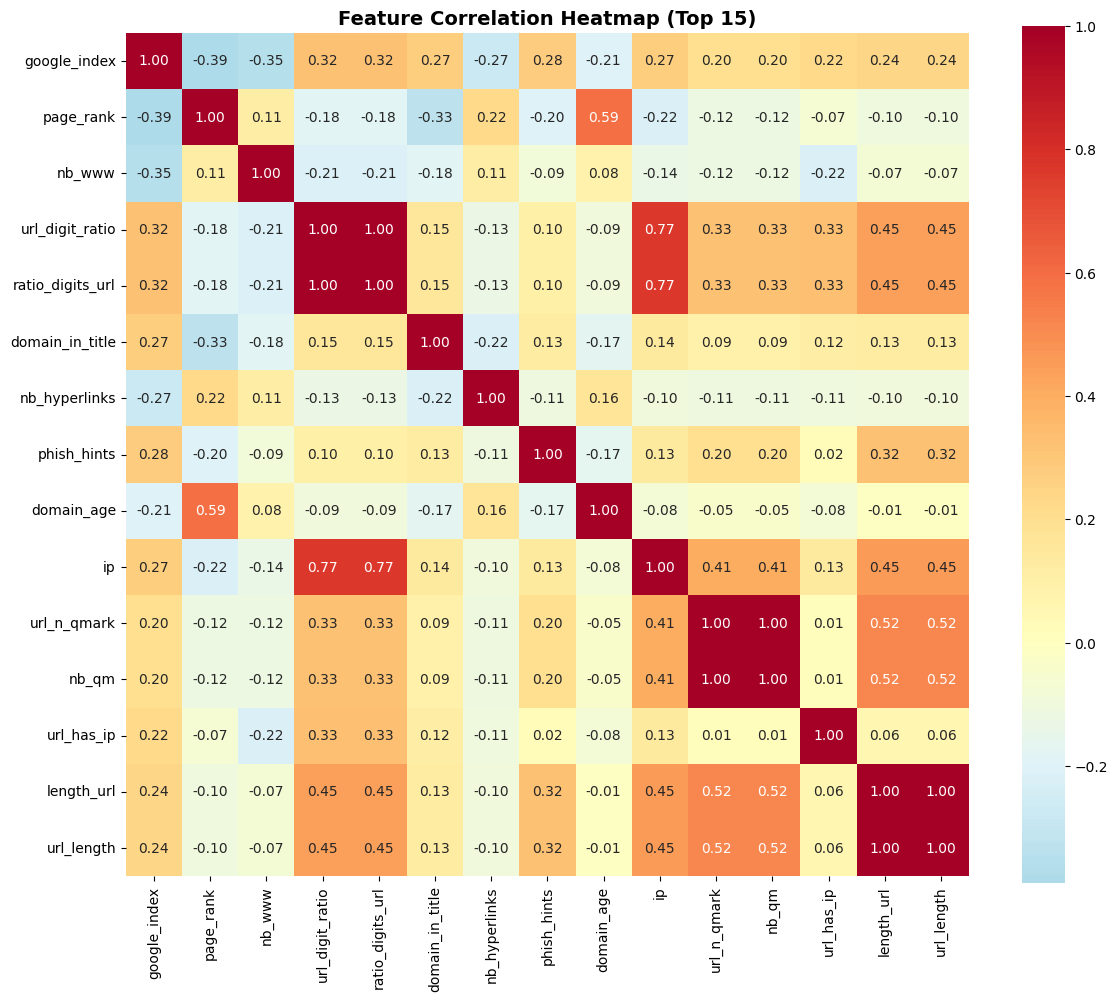

In [ ]:
# Correlation heatmap (top 15 features)
top_features = correlations.head(15).index.tolist()
fig, ax = plt.subplots(figsize=(12, 10))
correlation_matrix = X[top_features].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, ax=ax, square=True)
ax.set_title('Feature Correlation Heatmap (Top 15)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# %% [7] TRAIN-TEST SPLIT

print("=" * 60)
print("TRAIN-TEST SPLIT")
print("=" * 60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Training set: {X_train.shape[0]} samples")
print(f"✅ Test set: {X_test.shape[0]} samples")
print(f"✅ Training class distribution: {pd.Series(y_train).value_counts().to_dict()}")
print(f"✅ Test class distribution: {pd.Series(y_test).value_counts().to_dict()}")

TRAIN-TEST SPLIT
✅ Training set: 9144 samples
✅ Test set: 2286 samples
✅ Training class distribution: {0: 4572, 1: 4572}
✅ Test class distribution: {1: 1143, 0: 1143}


In [ ]:
# %% [8] MODEL TRAINING — RANDOM FOREST

print("=" * 60)
print("TRAINING: RANDOM FOREST")
print("=" * 60)

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)

TRAINING: RANDOM FOREST


RandomForestClassifier(class_weight='balanced', max_depth=20,
                       min_samples_leaf=2, min_samples_split=5,
                       n_estimators=200, n_jobs=-1, random_state=42)

In [ ]:
# Predictions
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [ ]:
# Metrics
print(f"\n📊 Random Forest Results:")
print(f"   Accuracy:  {accuracy_score(y_test, rf_pred):.4f}")
print(f"   Precision: {precision_score(y_test, rf_pred):.4f}")
print(f"   Recall:    {recall_score(y_test, rf_pred):.4f}")
print(f"   F1-Score:  {f1_score(y_test, rf_pred):.4f}")
print(f"   ROC-AUC:   {roc_auc_score(y_test, rf_prob):.4f}")

print(f"\n📊 Classification Report:")
print(classification_report(y_test, rf_pred))


📊 Random Forest Results:
   Accuracy:  0.9633
   Precision: 0.9592
   Recall:    0.9676
   F1-Score:  0.9634
   ROC-AUC:   0.9931

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.96      1143
           1       0.96      0.97      0.96      1143

    accuracy                           0.96      2286
   macro avg       0.96      0.96      0.96      2286
weighted avg       0.96      0.96      0.96      2286



In [ ]:
# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_cv_scores = cross_val_score(rf_model, X, y, cv=cv, scoring='f1', n_jobs=-1)
print(f"📊 Cross-Validation F1 (5-fold): {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}")

📊 Cross-Validation F1 (5-fold): 0.9654 ± 0.0048


In [ ]:
# %% [9] MODEL TRAINING — XGBOOST / GRADIENT BOOSTING

print("=" * 60)
if HAS_XGBOOST:
    print("TRAINING: XGBOOST")
else:
    print("TRAINING: GRADIENT BOOSTING (XGBoost fallback)")
print("=" * 60)

if HAS_XGBOOST:
    xgb_model = XGBClassifier(
        n_estimators=200,
        max_depth=8,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss',
        use_label_encoder=False
    )
else:
    xgb_model = GradientBoostingClassifier(
        n_estimators=200,
        max_depth=8,
        learning_rate=0.1,
        subsample=0.8,
        random_state=42
    )

xgb_model.fit(X_train, y_train)

# Predictions
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

# Metrics
model_name = "XGBoost" if HAS_XGBOOST else "Gradient Boosting"
print(f"\n📊 {model_name} Results:")
print(f"   Accuracy:  {accuracy_score(y_test, xgb_pred):.4f}")
print(f"   Precision: {precision_score(y_test, xgb_pred):.4f}")
print(f"   Recall:    {recall_score(y_test, xgb_pred):.4f}")
print(f"   F1-Score:  {f1_score(y_test, xgb_pred):.4f}")
print(f"   ROC-AUC:   {roc_auc_score(y_test, xgb_prob):.4f}")

print(f"\n📊 Classification Report:")
print(classification_report(y_test, xgb_pred))

# Cross-validation
xgb_cv_scores = cross_val_score(xgb_model, X, y, cv=cv, scoring='f1', n_jobs=-1)
print(f"📊 Cross-Validation F1 (5-fold): {xgb_cv_scores.mean():.4f} ± {xgb_cv_scores.std():.4f}")


TRAINING: XGBOOST

📊 XGBoost Results:
   Accuracy:  0.9676
   Precision: 0.9628
   Recall:    0.9729
   F1-Score:  0.9678
   ROC-AUC:   0.9948

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.97      1143
           1       0.96      0.97      0.97      1143

    accuracy                           0.97      2286
   macro avg       0.97      0.97      0.97      2286
weighted avg       0.97      0.97      0.97      2286

📊 Cross-Validation F1 (5-fold): 0.9693 ± 0.0025


In [ ]:
# %% [9.1] MODEL TRAINING — DECISION TREE

print("=" * 60)
print("TRAINING: DECISION TREE")
print("=" * 60)

dt_model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=42,
    class_weight='balanced'
)
dt_model.fit(X_train, y_train)

# Predictions
dt_pred = dt_model.predict(X_test)
dt_prob = dt_model.predict_proba(X_test)[:, 1]

# Metrics
print(f"\n📊 Decision Tree Results:")
print(f"   Accuracy:  {accuracy_score(y_test, dt_pred):.4f}")
print(f"   Precision: {precision_score(y_test, dt_pred):.4f}")
print(f"   Recall:    {recall_score(y_test, dt_pred):.4f}")
print(f"   F1-Score:  {f1_score(y_test, dt_pred):.4f}")
print(f"   ROC-AUC:   {roc_auc_score(y_test, dt_prob):.4f}")

print(f"\n📊 Classification Report:")
print(classification_report(y_test, dt_pred))

# Cross-validation
dt_cv_scores = cross_val_score(dt_model, X, y, cv=cv, scoring='f1', n_jobs=-1)
print(f"📊 Cross-Validation F1 (5-fold): {dt_cv_scores.mean():.4f} \u00b1 {dt_cv_scores.std():.4f}")

TRAINING: DECISION TREE

📊 Decision Tree Results:
   Accuracy:  0.9423
   Precision: 0.9415
   Recall:    0.9431
   F1-Score:  0.9423
   ROC-AUC:   0.9533

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      1143
           1       0.94      0.94      0.94      1143

    accuracy                           0.94      2286
   macro avg       0.94      0.94      0.94      2286
weighted avg       0.94      0.94      0.94      2286

📊 Cross-Validation F1 (5-fold): 0.9383 ± 0.0038


In [ ]:
# %% [9.2] MODEL TRAINING — SUPPORT VECTOR MACHINE (SVM)

print("=" * 60)
print("TRAINING: SUPPORT VECTOR MACHINE (SVM)")
print("=" * 60)

# SVMs are sensitive to feature scaling
svm_model = SVC(
    kernel='rbf', # Radial Basis Function kernel is common
    probability=True, # Required for roc_auc_score
    random_state=42,
    class_weight='balanced'
)
svm_model.fit(X_train_scaled, y_train)

# Predictions
svm_pred = svm_model.predict(X_test_scaled)
svm_prob = svm_model.predict_proba(X_test_scaled)[:, 1]

# Metrics
print(f"\n📊 SVM Results:")
print(f"   Accuracy:  {accuracy_score(y_test, svm_pred):.4f}")
print(f"   Precision: {precision_score(y_test, svm_pred):.4f}")
print(f"   Recall:    {recall_score(y_test, svm_pred):.4f}")
print(f"   F1-Score:  {f1_score(y_test, svm_pred):.4f}")
print(f"   ROC-AUC:   {roc_auc_score(y_test, svm_prob):.4f}")

print(f"\n📊 Classification Report:")
print(classification_report(y_test, svm_pred))

# Cross-validation (use scaled data for CV as well)
svm_cv_scores = cross_val_score(svm_model, scaler.fit_transform(X), y, cv=cv, scoring='f1', n_jobs=-1)
print(f"📊 Cross-Validation F1 (5-fold): {svm_cv_scores.mean():.4f} \u00b1 {svm_cv_scores.std():.4f}")

TRAINING: SUPPORT VECTOR MACHINE (SVM)

📊 SVM Results:
   Accuracy:  0.9519
   Precision: 0.9559
   Recall:    0.9475
   F1-Score:  0.9517
   ROC-AUC:   0.9885

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      1143
           1       0.96      0.95      0.95      1143

    accuracy                           0.95      2286
   macro avg       0.95      0.95      0.95      2286
weighted avg       0.95      0.95      0.95      2286

📊 Cross-Validation F1 (5-fold): 0.9588 ± 0.0031


In [ ]:
# %% [9.3] MODEL TRAINING — NEURAL NETWORK (MLPClassifier)

print("=" * 60)
print("TRAINING: NEURAL NETWORK (MLPClassifier)")
print("=" * 60)

mlp_model = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    max_iter=500,
    activation='relu',
    solver='adam',
    random_state=42,
    early_stopping=True,
    n_iter_no_change=10
    # class_weight='balanced'  # Removed as MLPClassifier does not support this
)
mlp_model.fit(X_train_scaled, y_train)

# Predictions
mlp_pred = mlp_model.predict(X_test_scaled)
mlp_prob = mlp_model.predict_proba(X_test_scaled)[:, 1]

# Metrics
print(f"\n📊 Neural Network Results:")
print(f"   Accuracy:  {accuracy_score(y_test, mlp_pred):.4f}")
print(f"   Precision: {precision_score(y_test, mlp_pred):.4f}")
print(f"   Recall:    {recall_score(y_test, mlp_pred):.4f}")
print(f"   F1-Score:  {f1_score(y_test, mlp_pred):.4f}")
print(f"   ROC-AUC:   {roc_auc_score(y_test, mlp_prob):.4f}")

print(f"\n📊 Classification Report:")
print(classification_report(y_test, mlp_pred))

# Cross-validation (use scaled data for CV as well)
mlp_cv_scores = cross_val_score(mlp_model, scaler.fit_transform(X), y, cv=cv, scoring='f1', n_jobs=-1)
print(f"📊 Cross-Validation F1 (5-fold): {mlp_cv_scores.mean():.4f} \u00b1 {mlp_cv_scores.std():.4f}")

TRAINING: NEURAL NETWORK (MLPClassifier)

📊 Neural Network Results:
   Accuracy:  0.9571
   Precision: 0.9595
   Recall:    0.9545
   F1-Score:  0.9570
   ROC-AUC:   0.9909

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.96      1143
           1       0.96      0.95      0.96      1143

    accuracy                           0.96      2286
   macro avg       0.96      0.96      0.96      2286
weighted avg       0.96      0.96      0.96      2286

📊 Cross-Validation F1 (5-fold): 0.9592 ± 0.0027


In [ ]:
# %% [9.4] CONSOLIDATE ALL MODEL RESULTS

print("=" * 60)
print("CONSOLIDATING MODEL RESULTS")
print("=" * 60)

all_models_results = []

# Add Random Forest results
all_models_results.append({
    'name': 'Random Forest',
    'model': rf_model,
    'predictions': rf_pred,
    'probabilities': rf_prob,
    'accuracy': accuracy_score(y_test, rf_pred),
    'precision': precision_score(y_test, rf_pred),
    'recall': recall_score(y_test, rf_pred),
    'f1': f1_score(y_test, rf_pred),
    'roc_auc': roc_auc_score(y_test, rf_prob)
})

# Add XGBoost/Gradient Boosting results
# model_name is already defined as 'XGBoost' or 'Gradient Boosting'
all_models_results.append({
    'name': model_name,
    'model': xgb_model,
    'predictions': xgb_pred,
    'probabilities': xgb_prob,
    'accuracy': accuracy_score(y_test, xgb_pred),
    'precision': precision_score(y_test, xgb_pred),
    'recall': recall_score(y_test, xgb_pred),
    'f1': f1_score(y_test, xgb_pred),
    'roc_auc': roc_auc_score(y_test, xgb_prob)
})

# Add Decision Tree results
all_models_results.append({
    'name': 'Decision Tree',
    'model': dt_model,
    'predictions': dt_pred,
    'probabilities': dt_prob,
    'accuracy': accuracy_score(y_test, dt_pred),
    'precision': precision_score(y_test, dt_pred),
    'recall': recall_score(y_test, dt_pred),
    'f1': f1_score(y_test, dt_pred),
    'roc_auc': roc_auc_score(y_test, dt_prob)
})

# Add SVM results (using scaled data for predictions and probabilities)
all_models_results.append({
    'name': 'SVM',
    'model': svm_model,
    'predictions': svm_pred,
    'probabilities': svm_prob,
    'accuracy': accuracy_score(y_test, svm_pred),
    'precision': precision_score(y_test, svm_pred),
    'recall': recall_score(y_test, svm_pred),
    'f1': f1_score(y_test, svm_pred),
    'roc_auc': roc_auc_score(y_test, svm_prob)
})

# Add Neural Network results (using scaled data for predictions and probabilities)
all_models_results.append({
    'name': 'Neural Network',
    'model': mlp_model,
    'predictions': mlp_pred,
    'probabilities': mlp_prob,
    'accuracy': accuracy_score(y_test, mlp_pred),
    'precision': precision_score(y_test, mlp_pred),
    'recall': recall_score(y_test, mlp_pred),
    'f1': f1_score(y_test, mlp_pred),
    'roc_auc': roc_auc_score(y_test, mlp_prob)
})

print(f"✅ Consolidated results for {len(all_models_results)} models.")

CONSOLIDATING MODEL RESULTS
✅ Consolidated results for 5 models.


MODEL COMPARISON


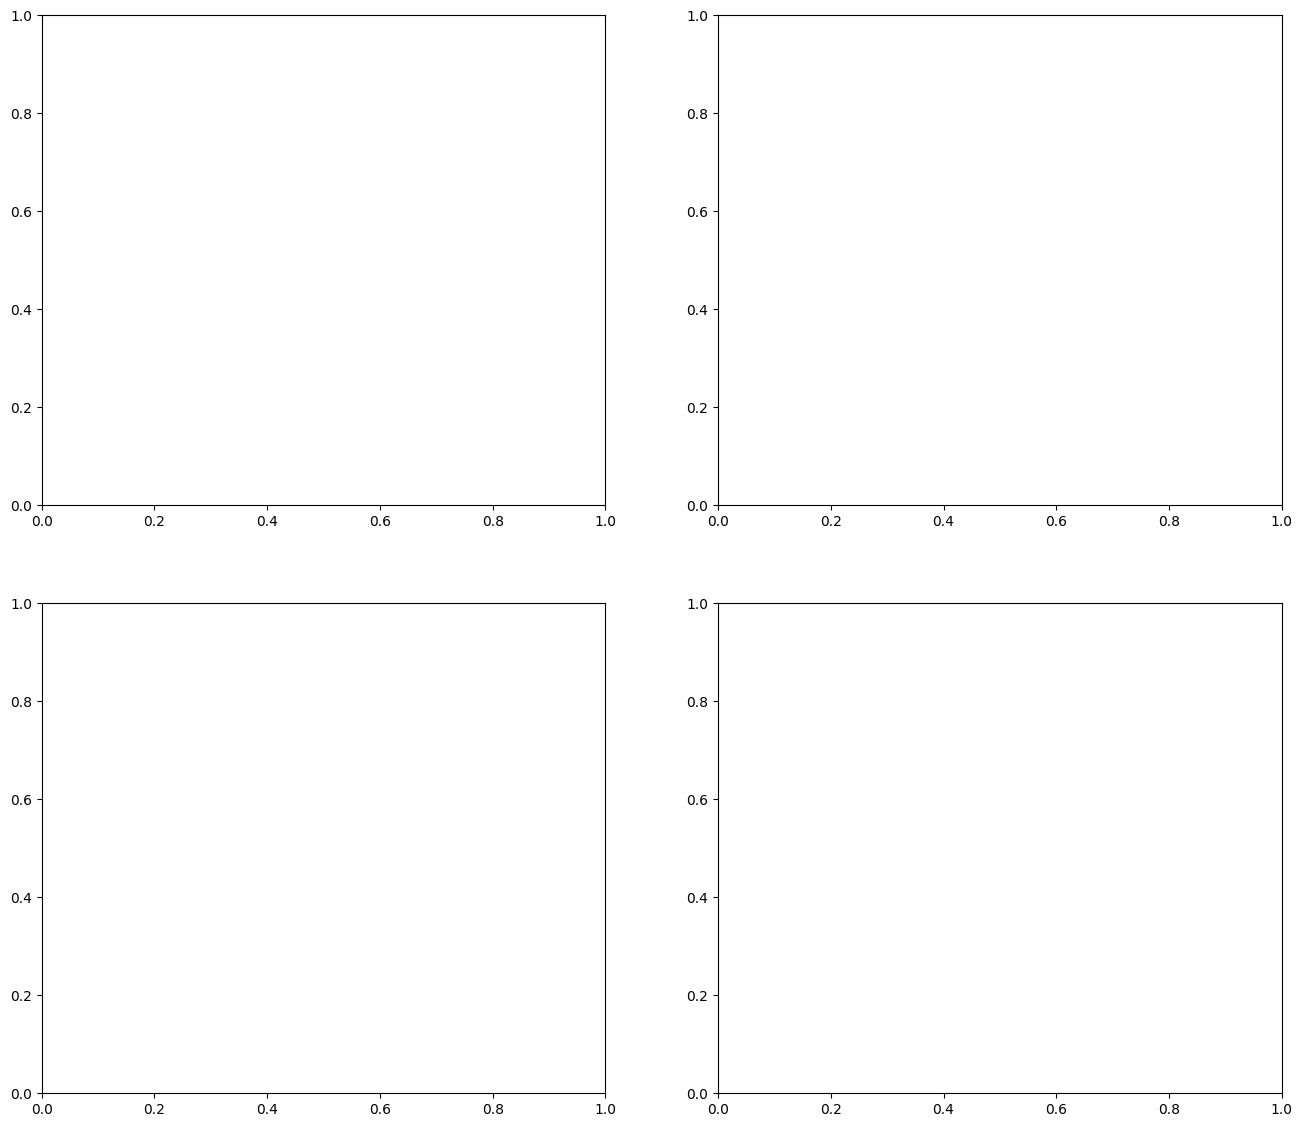

In [ ]:
# %% [10] MODEL COMPARISON & VISUALIZATION

print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

In [ ]:
# --- ROC Curves ---
axes[0, 0].plot([0,1], [0,1], 'k--', alpha=0.5)
for model_res in all_models_results:
    fpr, tpr, _ = roc_curve(y_test, model_res['probabilities'])
    axes[0, 0].plot(fpr, tpr, linewidth=2, label=f"{model_res['name']} (AUC={model_res['roc_auc']:.4f})")

axes[0, 0].set_xlabel('False Positive Rate')
axes[0, 0].set_ylabel('True Positive Rate')
axes[0, 0].set_title('ROC Curve Comparison', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

In [ ]:
# --- Metrics Comparison Bar Chart ---
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
results_df = pd.DataFrame(all_models_results)

# Create a melted dataframe for easier plotting
melted_df = results_df.melt(id_vars=['name'], value_vars=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
                            var_name='metric', value_name='score')

# Map metric names to display names
metric_display_names = {
    'accuracy': 'Accuracy',
    'precision': 'Precision',
    'recall': 'Recall',
    'f1': 'F1-Score',
    'roc_auc': 'ROC-AUC'
}
melted_df['metric'] = melted_df['metric'].map(metric_display_names)

sns.barplot(x='metric', y='score', hue='name', data=melted_df, ax=axes[0, 1], palette='deep')
axes[0, 1].set_title('Metrics Comparison', fontweight='bold')
axes[0, 1].set_xlabel('Metric')
axes[0, 1].set_ylabel('Score')
axes[0, 1].set_ylim(0.5, 1.05) # Adjust if necessary
axes[0, 1].legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0, 1].grid(True, alpha=0.3, axis='y')

RE-GENERATING MODEL COMPARISON


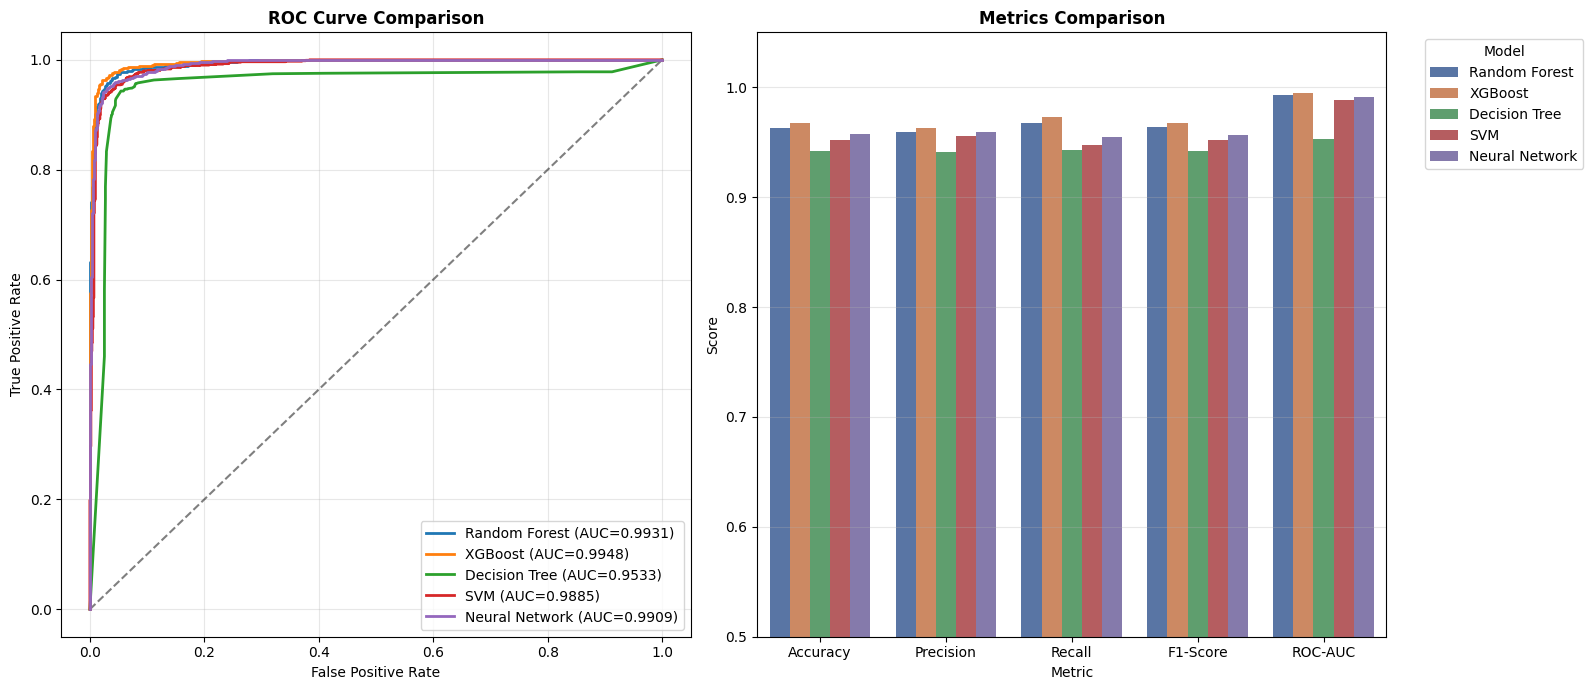

✅ Model comparison chart saved as 'model_comparison.png'


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("=" * 60)
print("RE-GENERATING MODEL COMPARISON")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(16, 7)) # Adjust layout if needed

# --- ROC Curves ---
axes[0].plot([0,1], [0,1], 'k--', alpha=0.5)
for model_res in all_models_results:
    fpr, tpr, _ = roc_curve(y_test, model_res['probabilities'])
    axes[0].plot(fpr, tpr, linewidth=2, label=f"{model_res['name']} (AUC={model_res['roc_auc']:.4f})")

axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve Comparison', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Metrics Comparison Bar Chart ---
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
results_df = pd.DataFrame(all_models_results)

# Create a melted dataframe for easier plotting
melted_df = results_df.melt(id_vars=['name'], value_vars=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
                            var_name='metric', value_name='score')

# Map metric names to display names
metric_display_names = {
    'accuracy': 'Accuracy',
    'precision': 'Precision',
    'recall': 'Recall',
    'f1': 'F1-Score',
    'roc_auc': 'ROC-AUC'
}
melted_df['metric'] = melted_df['metric'].map(metric_display_names)

sns.barplot(x='metric', y='score', hue='name', data=melted_df, ax=axes[1], palette='deep')
axes[1].set_title('Metrics Comparison', fontweight='bold')
axes[1].set_xlabel('Metric')
axes[1].set_ylabel('Score')
axes[1].set_ylim(0.5, 1.05) # Adjust if necessary
axes[1].legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Model comparison chart saved as 'model_comparison.png'")

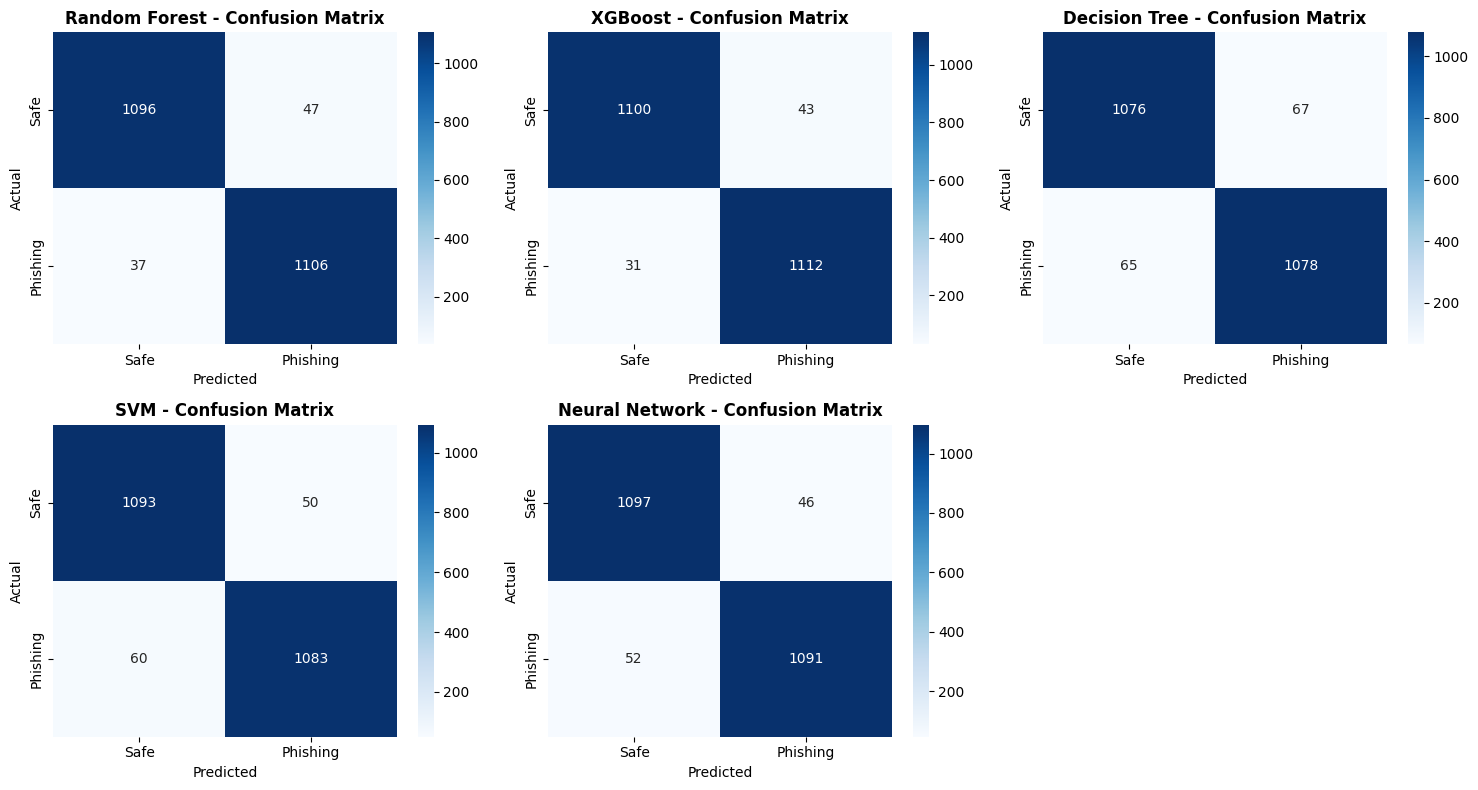

✅ All model confusion matrices saved as 'all_model_confusion_matrices.png'


In [ ]:
# --- Confusion Matrices ---
# Determine grid size for subplots
num_models = len(all_models_results)
n_cols = min(num_models, 3) # Max 3 columns
n_rows = (num_models + n_cols - 1) // n_cols # Calculate rows needed

fig_cm, axes_cm = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes_cm = axes_cm.flatten() # Flatten for easy iteration

for i, model_res in enumerate(all_models_results):
    cm = confusion_matrix(y_test, model_res['predictions'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_cm[i],
                xticklabels=['Safe', 'Phishing'], yticklabels=['Safe', 'Phishing'])
    axes_cm[i].set_title(f"{model_res['name']} - Confusion Matrix", fontweight='bold')
    axes_cm[i].set_ylabel('Actual')
    axes_cm[i].set_xlabel('Predicted')

# Hide unused subplots if any
for j in range(i + 1, len(axes_cm)):
    fig_cm.delaxes(axes_cm[j])

plt.tight_layout()
plt.savefig('all_model_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ All model confusion matrices saved as 'all_model_confusion_matrices.png'")

In [ ]:
# %% [12] SELECT BEST MODEL & EXPORT

print("=" * 60)
print("MODEL SELECTION & EXPORT")
print("=" * 60)

MODEL SELECTION & EXPORT


In [ ]:
# Compare F1 scores to choose best model
best_f1_score = -1
best_model_info = None

for model_res in all_models_results:
    if model_res['f1'] > best_f1_score:
        best_f1_score = model_res['f1']
        best_model_info = model_res

best_model = best_model_info['model']
best_name = best_model_info['name']
best_f1 = best_f1_score
best_pred = best_model_info['predictions']
best_prob = best_model_info['probabilities'] # Ensure best_prob is available for ROC-AUC export

print(f"🏆 Best Model: {best_name} (F1 = {best_f1:.4f})")

🏆 Best Model: XGBoost (F1 = 0.9678)


In [ ]:
# Export model
model_filename = 'model_training_ml.pkl'
joblib.dump({
    'model': best_model,
    'scaler': scaler,
    'model_name': best_name,
    'feature_columns': feature_cols,
    'target_mapping': target_mapping,
    'train_accuracy': accuracy_score(y_train, best_model.predict(X_train)),
    'test_accuracy': accuracy_score(y_test, best_model.predict(X_test)),
    'test_f1': best_f1,
}, model_filename)

print(f"✅ Model saved to: {model_filename}")

✅ Model saved to: model_training.pkl


In [ ]:
# Export feature config
feature_config = {
    'feature_columns': feature_cols,
    'target_mapping': target_mapping,
    'model_name': best_name,
    'threshold': 0.5,
    'performance': {
        'accuracy': float(accuracy_score(y_test, best_model.predict(X_test))),
        'precision': float(precision_score(y_test, best_model.predict(X_test))),
        'recall': float(recall_score(y_test, best_model.predict(X_test))),
        'f1': float(best_f1),
        'roc_auc': float(roc_auc_score(y_test, best_prob))
    }
}

config_filename = 'feature_config.json'
with open(config_filename, 'w') as f:
    json.dump(feature_config, f, indent=2)

print(f"✅ Feature config saved to: {config_filename}")

✅ Feature config saved to: feature_config.json


FEATURE IMPORTANCE


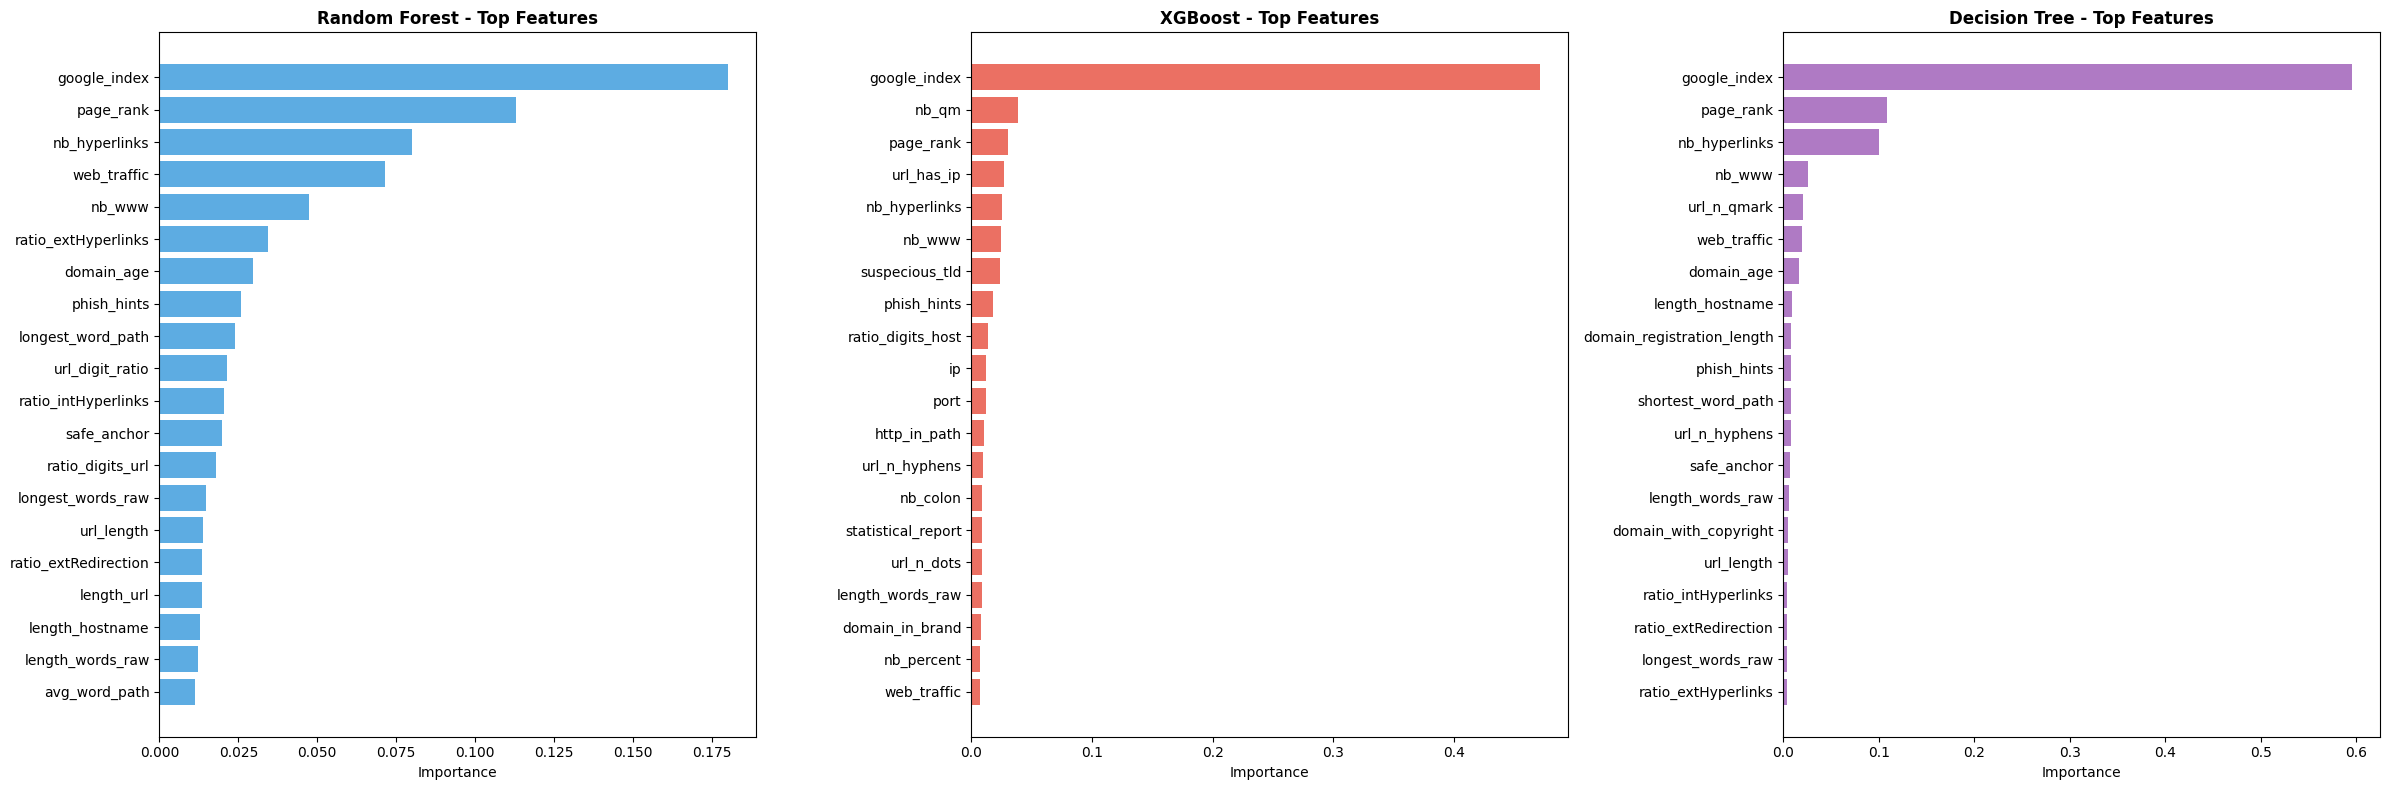

✅ Feature importance chart saved as 'feature_importance.png'

📊 Top 10 Most Important Features for tree-based models:

--- Random Forest ---
            feature  importance
       google_index    0.179996
          page_rank    0.112907
      nb_hyperlinks    0.079955
        web_traffic    0.071510
             nb_www    0.047270
ratio_extHyperlinks    0.034253
         domain_age    0.029735
        phish_hints    0.025917
  longest_word_path    0.023877
    url_digit_ratio    0.021524

--- XGBoost ---
          feature  importance
     google_index    0.470869
            nb_qm    0.038516
        page_rank    0.030687
       url_has_ip    0.027101
    nb_hyperlinks    0.025581
           nb_www    0.024475
   suspecious_tld    0.023710
      phish_hints    0.017532
ratio_digits_host    0.013376
               ip    0.012445

--- Decision Tree ---
                   feature  importance
              google_index    0.595200
                 page_rank    0.108117
             nb_hype

In [ ]:
# %% [11] FEATURE IMPORTANCE

print("=" * 60)
print("FEATURE IMPORTANCE")
print("=" * 60)

# Filter for models that have feature importances
models_with_importance = [model_res for model_res in all_models_results if hasattr(model_res['model'], 'feature_importances_')]
num_importance_plots = len(models_with_importance)

if num_importance_plots > 0:
    fig_fi, axes_fi = plt.subplots(1, num_importance_plots, figsize=(8 * num_importance_plots, 8))
    if num_importance_plots == 1:
        axes_fi = [axes_fi] # Make it iterable if only one subplot

    plot_idx = 0
    colors = ['#3498db', '#e74c3c', '#9b59b6', '#2ecc71', '#f1c40f', '#e67e22'] # More colors for variety

    for model_res in models_with_importance:
        importance_df = pd.DataFrame({
            'feature': feature_cols,
            'importance': model_res['model'].feature_importances_
        }).sort_values('importance', ascending=False)

        top_n = min(20, len(importance_df)) # Limit to top 20 or fewer features
        axes_fi[plot_idx].barh(importance_df['feature'][:top_n][::-1],
                               importance_df['importance'][:top_n][::-1],
                               color=colors[plot_idx % len(colors)], alpha=0.8)
        axes_fi[plot_idx].set_xlabel('Importance')
        axes_fi[plot_idx].set_title(f"{model_res['name']} - Top Features", fontweight='bold')
        plot_idx += 1

    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("✅ Feature importance chart saved as 'feature_importance.png'")

    # Also print top 10 for each
    print("\n📊 Top 10 Most Important Features for tree-based models:")
    for model_res in models_with_importance:
        importance_df = pd.DataFrame({
            'feature': feature_cols,
            'importance': model_res['model'].feature_importances_
        }).sort_values('importance', ascending=False)
        print(f"\n--- {model_res['name']} ---")
        print(importance_df.head(10).to_string(index=False))
else:
    print("No models with direct feature_importances_ attribute found for plotting.")


In [ ]:
# %% [13] DOWNLOAD FILES (Google Colab only)

print("=" * 60)
print("DOWNLOAD EXPORTED FILES")
print("=" * 60)

print(f"""
📦 Files to download:
   1. {model_filename} — Trained ML model (place in backend/models/)
   2. {config_filename} — Feature configuration (place in backend/models/)
   3. model_comparison.png — Model comparison chart
   4. feature_importance.png — Feature importance chart
""")

DOWNLOAD EXPORTED FILES

📦 Files to download:
   1. model_training.pkl — Trained ML model (place in backend/models/)
   2. feature_config.json — Feature configuration (place in backend/models/)
   3. model_comparison.png — Model comparison chart
   4. feature_importance.png — Feature importance chart



In [ ]:
# Uncomment for Google Colab to auto-download:
from google.colab import files
files.download(model_filename)
files.download(config_filename)
files.download('model_comparison.png')
files.download('feature_importance.png')

print("✅ Done! Copy the .pkl and .json files to your local backend/models/ directory.")
print("   Then run your Flask backend to use the trained model for real-time inference.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Done! Copy the .pkl and .json files to your local backend/models/ directory.
   Then run your Flask backend to use the trained model for real-time inference.
